### 1. Import Libraries & Load Data

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# Load data
df = pd.read_csv('../data/train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (891, 12)
Rows: 891 | Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Data Overview

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Statistical summary for nummeric
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [5]:
# Statistical summary for object
df.describe(include='object').round(2)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


### 3. Missing Value Analysis

In [6]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)# 
print(missing)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


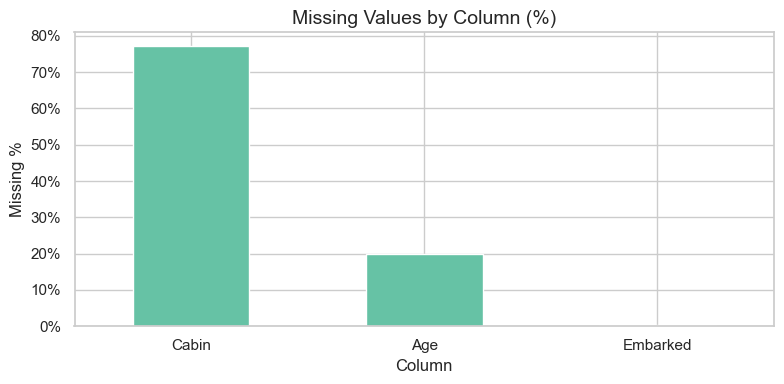

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing['Missing %'].plot(kind='bar', color=sns.color_palette('Set2')[0], ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()) # định dạng cột y là %
plt.xticks(rotation=0)# dùng để chữ ở cột x theo chiều ngang
plt.tight_layout()#dùng để Matplotlib tự chỉnh khoảng cách bố cục cho hình vẽ.
plt.savefig('../screenshots/Percent_of_Missing_Values.png')
plt.show()

### 4.Univariate Analysis

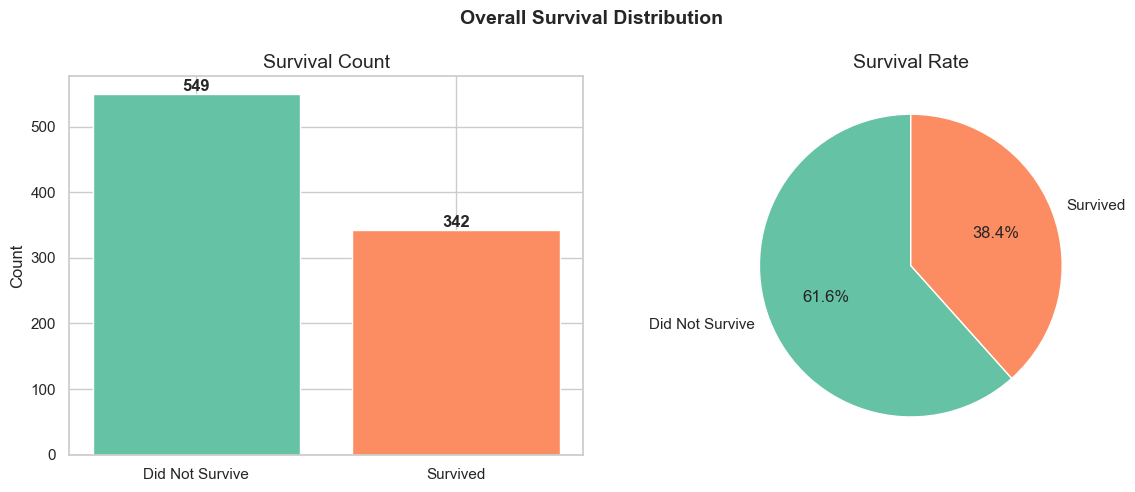

Survival Rate: 38.4%
Non-Survival Rate: 61.6%


In [9]:
# Overall survival rate
survival_counts = df['Survived'].value_counts()
survival_pct = df['Survived'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['Did Not Survive', 'Survived'], survival_counts.values,
            color=sns.color_palette('Set2')[:2])
axes[0].set_title('Survival Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survival_pct.values, labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2')[:2],
            startangle=90)
axes[1].set_title('Survival Rate')

plt.suptitle('Overall Survival Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Overall_Survival_Distribution.png')
plt.show()

print(f'Survival Rate: {survival_pct[1]:.1f}%')
print(f'Non-Survival Rate: {survival_pct[0]:.1f}%')


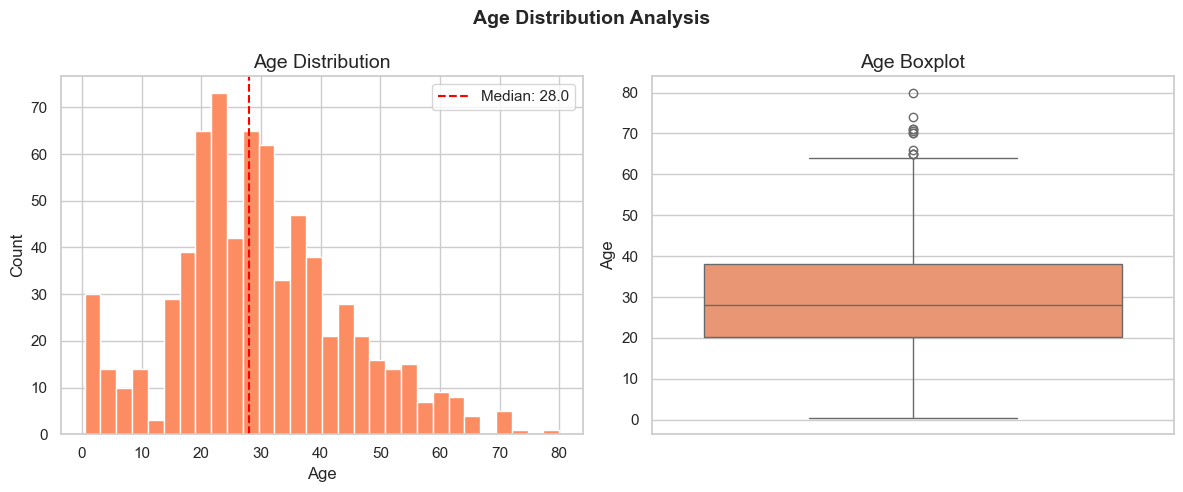

Mean Age: 29.7
Median Age: 28.0
Age Range: 0.42 - 80.0


In [10]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Age'].dropna(), bins=30, color=sns.color_palette('Set2')[1], edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median()}')
axes[0].legend()

sns.boxplot(y=df['Age'], ax=axes[1], color=sns.color_palette('Set2')[1])
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')

plt.suptitle('Age Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Age_Distribution_Analysis.png')
plt.show()

print(f'Mean Age: {df["Age"].mean():.1f}')
print(f'Median Age: {df["Age"].median()}')
print(f'Age Range: {df["Age"].min()} - {df["Age"].max()}')

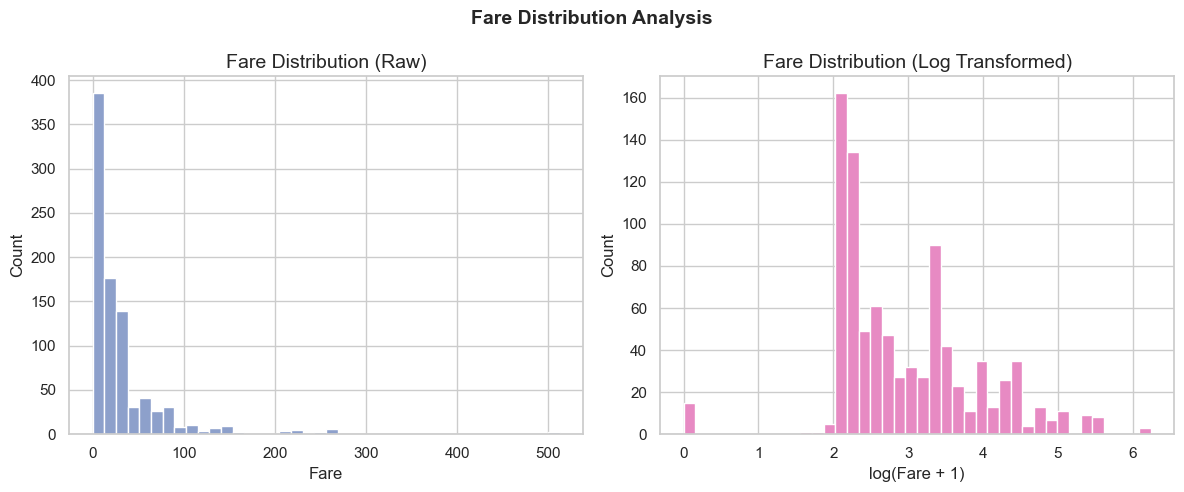

Mean Fare: $32.20
Median Fare: $14.45
Max Fare: $512.33


In [11]:
# Fare distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'], bins=40, color=sns.color_palette('Set2')[2], edgecolor='white')
axes[0].set_title('Fare Distribution (Raw)')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Fare']), bins=40, color=sns.color_palette('Set2')[3], edgecolor='white')
axes[1].set_title('Fare Distribution (Log Transformed)')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Fare Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Fare_Distribution_Analysis.png')
plt.show()

print(f'Mean Fare: ${df["Fare"].mean():.2f}')
print(f'Median Fare: ${df["Fare"].median():.2f}')
print(f'Max Fare: ${df["Fare"].max():.2f}')


C:\Users\Song\AppData\Local\Temp\ipykernel_18352\1468183425.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)'])


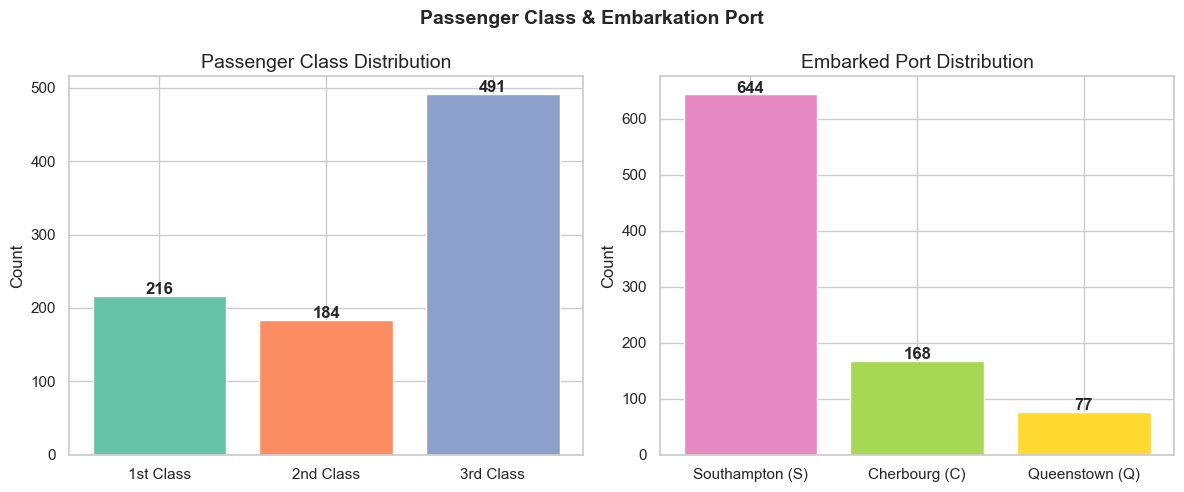

In [12]:
# Passenger class and Embarked distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0].bar(['1st Class', '2nd Class', '3rd Class'], pclass_counts.values,
            color=sns.color_palette('Set2')[:3])
axes[0].set_title('Passenger Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(pclass_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

embarked_counts = df['Embarked'].value_counts()
axes[1].bar(embarked_counts.index, embarked_counts.values,
            color=sns.color_palette('Set2')[3:6])
axes[1].set_title('Embarked Port Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)'])
for i, v in enumerate(embarked_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Passenger Class & Embarkation Port', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Passenger_Class_and_Embarkation_Port.png')
plt.show()

### 5. Bivariate Analysis

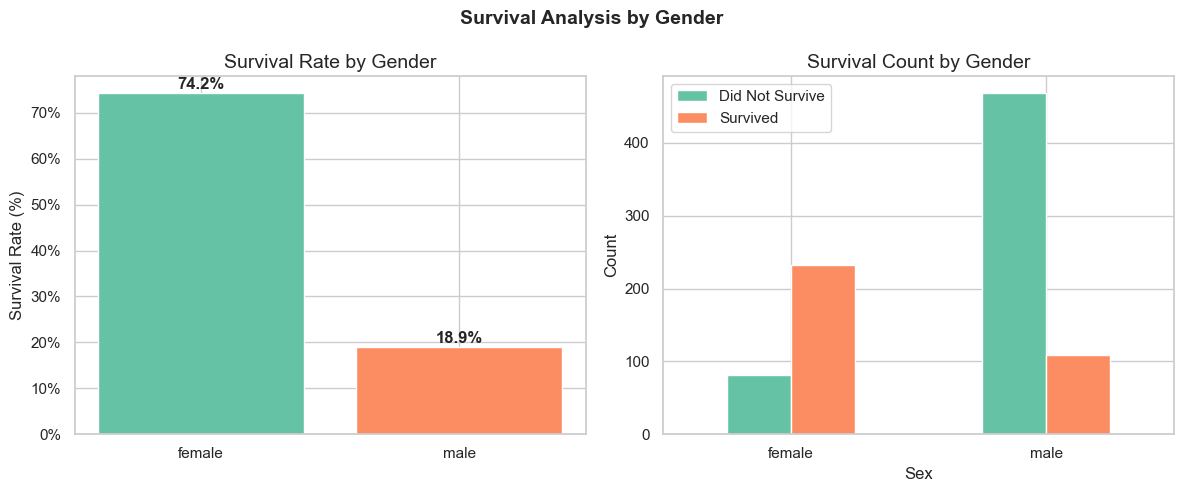

Female Survival Rate: 74.2%
Male Survival Rate: 18.9%


In [13]:
# Survival by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(gender_survival.index, gender_survival.values,
            color=sns.color_palette('Set2')[:2])
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(gender_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

gender_counts = df.groupby(['Sex', 'Survived']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2')[:2],
                   rot=0)
axes[1].set_title('Survival Count by Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['Did Not Survive', 'Survived'])

plt.suptitle('Survival Analysis by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Survival_Analysis_by_Gender.png')
plt.show()

print(f'Female Survival Rate: {gender_survival["female"]:.1f}%')
print(f'Male Survival Rate: {gender_survival["male"]:.1f}%')

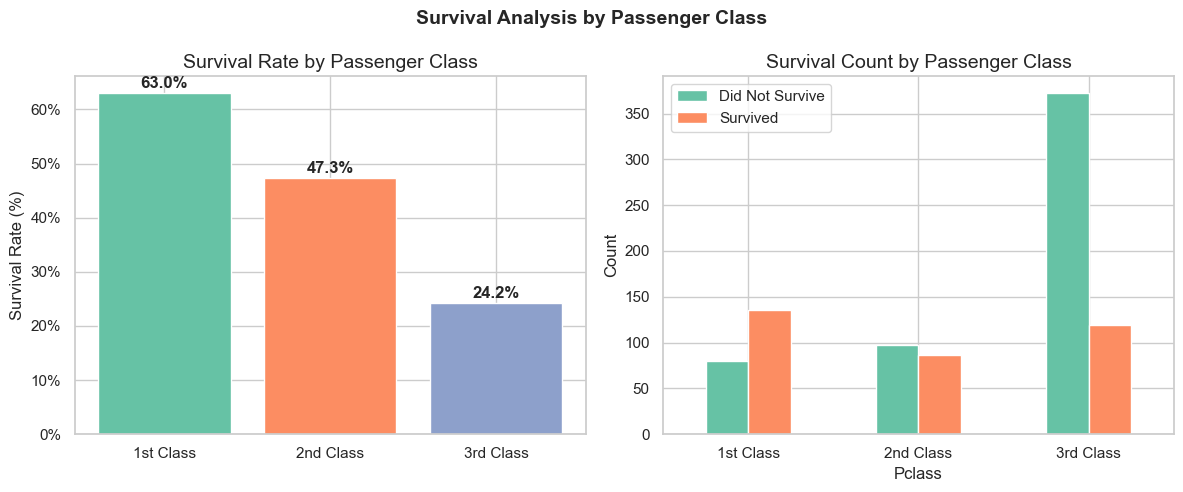

In [14]:
# Survival by passenger class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[0].bar(['1st Class', '2nd Class', '3rd Class'], pclass_survival.values,
            color=sns.color_palette('Set2')[:3])
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(pclass_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

pclass_counts = df.groupby(['Pclass', 'Survived']).size().unstack()
pclass_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2')[:2], rot=0)
axes[1].set_title('Survival Count by Passenger Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[1].legend(['Did Not Survive', 'Survived'])

plt.suptitle('Survival Analysis by Passenger Class', fontsize=14, fontweight='bold')
plt.savefig('../screenshots/Survival_Analysis_by_Passenger_Class.png')
plt.tight_layout()
plt.show()

C:\Users\Song\AppData\Local\Temp\ipykernel_18352\2202349204.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
C:\Users\Song\AppData\Local\Temp\ipykernel_18352\2202349204.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1],
C:\Users\Song\AppData\Local\Temp\ipykernel_18352\2202349204.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Did Not Survive', 'Survived'])


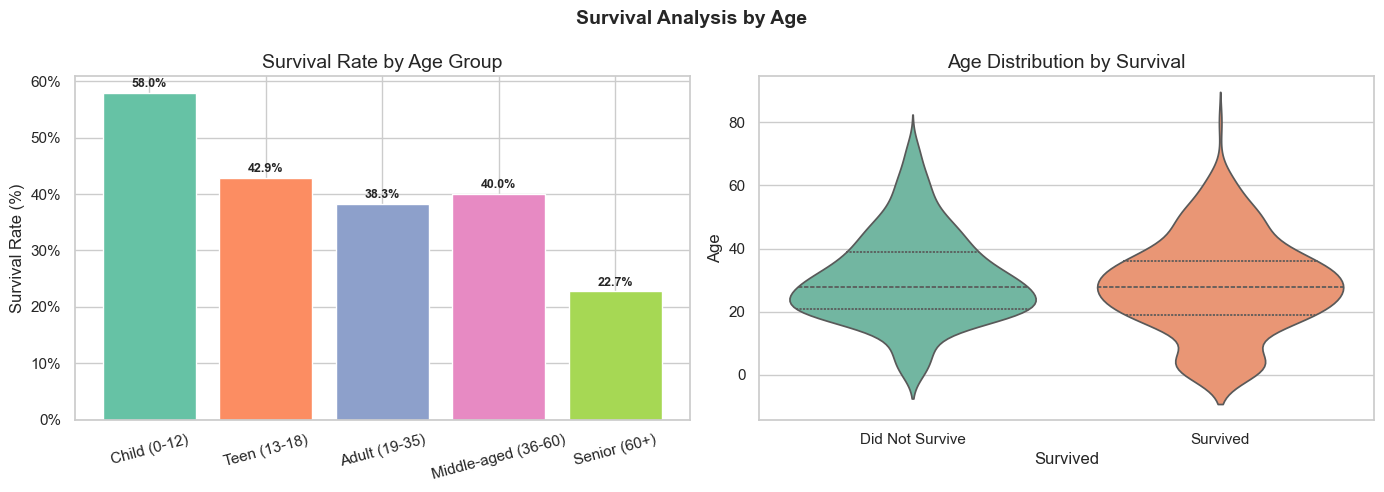

In [15]:
# Survival by age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)',
                                 'Middle-aged (36-60)', 'Senior (60+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
axes[0].bar(age_survival.index, age_survival.values,
            color=sns.color_palette('Set2', len(age_survival)))
axes[0].set_title('Survival Rate by Age Group')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(age_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1],
               palette='Set2', inner='quartile')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
axes[1].set_ylabel('Age')

plt.suptitle('Survival Analysis by Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Survival_Analysis_by_Age.png')
plt.show()

C:\Users\Song\AppData\Local\Temp\ipykernel_18352\1864356050.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])
C:\Users\Song\AppData\Local\Temp\ipykernel_18352\1864356050.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Embarked', y='Fare', ax=axes[1], palette='Set2')
C:\Users\Song\AppData\Local\Temp\ipykernel_18352\1864356050.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])


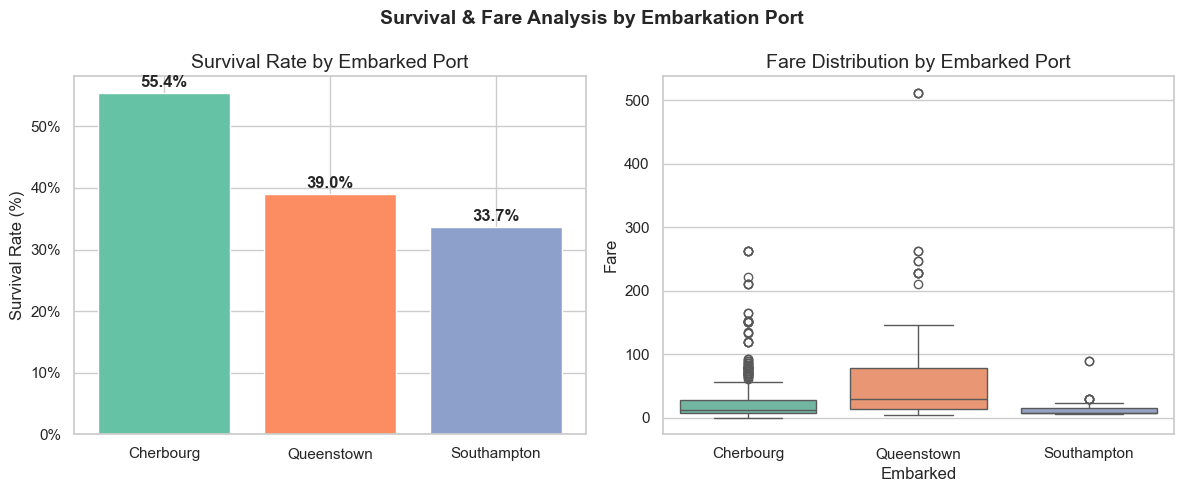

In [16]:
# Survival by embarked port
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100
axes[0].bar(embarked_survival.index, embarked_survival.values,
            color=sns.color_palette('Set2')[:3])
axes[0].set_title('Survival Rate by Embarked Port')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])
for i, v in enumerate(embarked_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

sns.boxplot(data=df, x='Embarked', y='Fare', ax=axes[1], palette='Set2')
axes[1].set_title('Fare Distribution by Embarked Port')
axes[1].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])
axes[1].set_ylabel('Fare')

plt.suptitle('Survival & Fare Analysis by Embarkation Port', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/Survival_and_Fare_Analysis_by_Embarkation_Port.png')
plt.show()

### 6. Multivariate Analysis

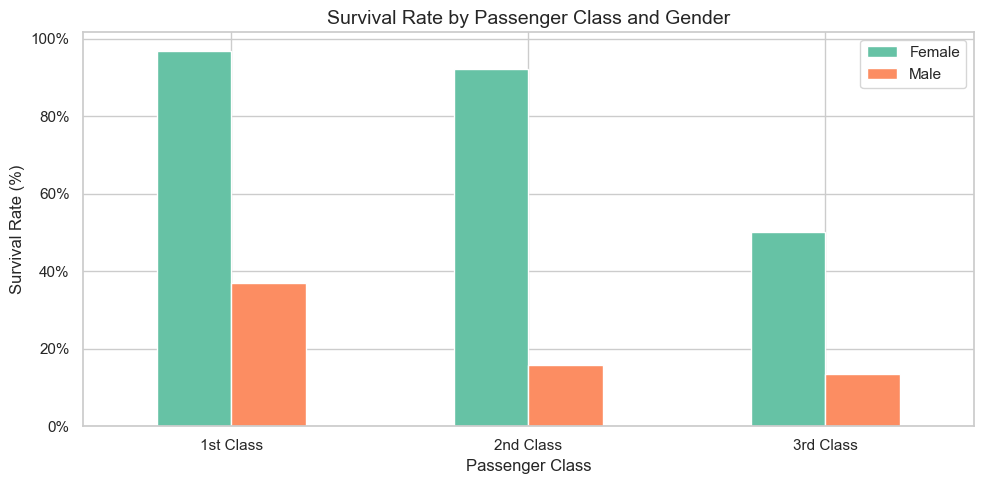

In [17]:
# Survival by class and gender
fig, ax = plt.subplots(figsize=(10, 5))

class_gender_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
class_gender_survival.plot(kind='bar', ax=ax, color=sns.color_palette('Set2')[:2], rot=0)
ax.set_title('Survival Rate by Passenger Class and Gender')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.legend(['Female', 'Male'])

plt.tight_layout()
plt.savefig('../screenshots/Survival_Rate_by_Passenger_Class_and_Gender.png')
plt.show()

C:\Users\Song\AppData\Local\Temp\ipykernel_18352\699081158.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(group['Age'], np.log1p(group['Fare']),


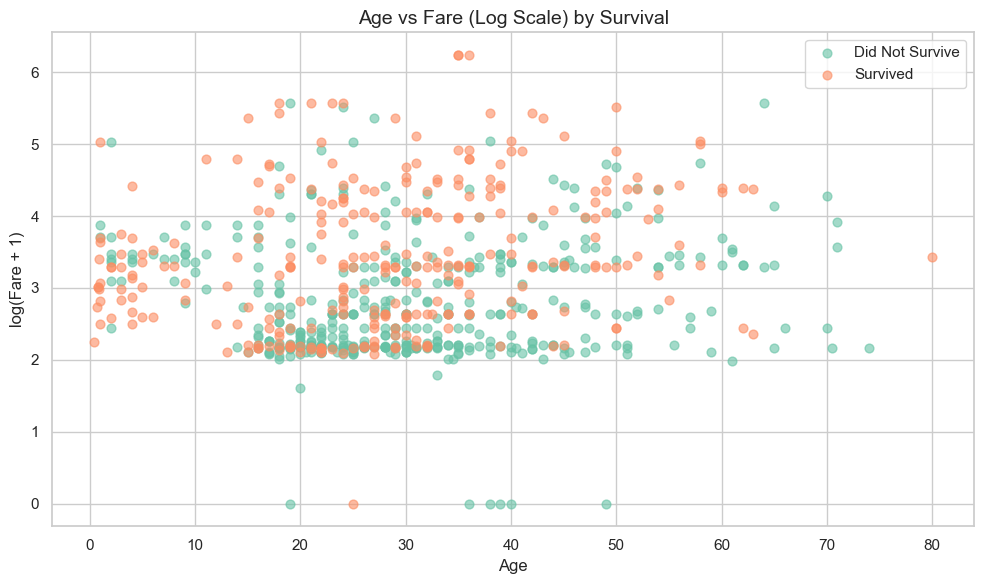

In [18]:
# Age vs Fare scatter colored by survival
fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: sns.color_palette('Set2')[0], 1: sns.color_palette('Set2')[1]}
for survived, group in df.groupby('Survived'):
    ax.scatter(group['Age'], np.log1p(group['Fare']),
               c=colors[survived], label='Survived' if survived else 'Did Not Survive',
               alpha=0.6, s=40)

ax.set_title('Age vs Fare (Log Scale) by Survival')
ax.set_xlabel('Age')
ax.set_ylabel('log(Fare + 1)')
ax.legend()
plt.tight_layout()
plt.savefig('../screenshots/Age_vs_Fare_by_Survival.png')
plt.show()

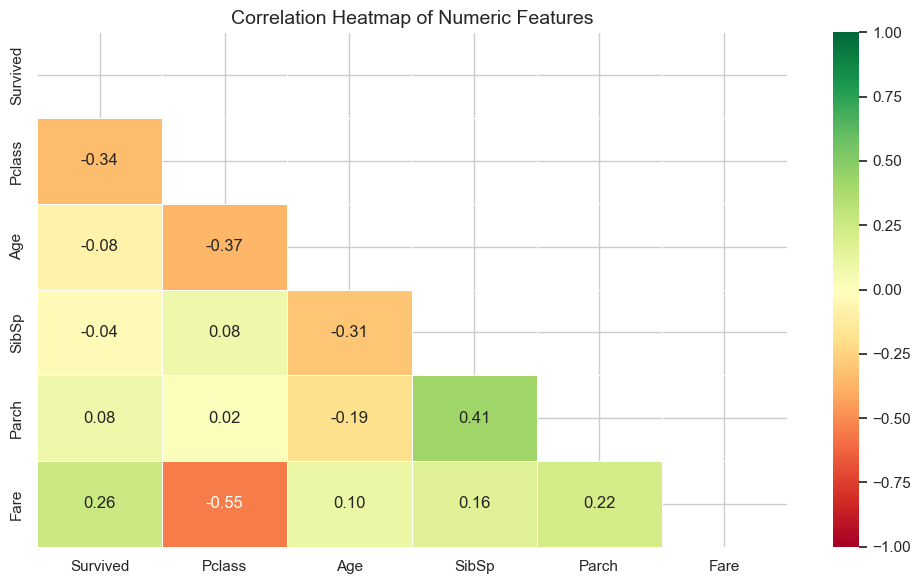

In [19]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 6))

numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, center=0)
ax.set_title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../screenshots/Correlation Heatmap of Numeric Features.png')
plt.show()

C:\Users\Song\AppData\Local\Temp\ipykernel_18352\3465705770.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='Survived', index='AgeGroup',


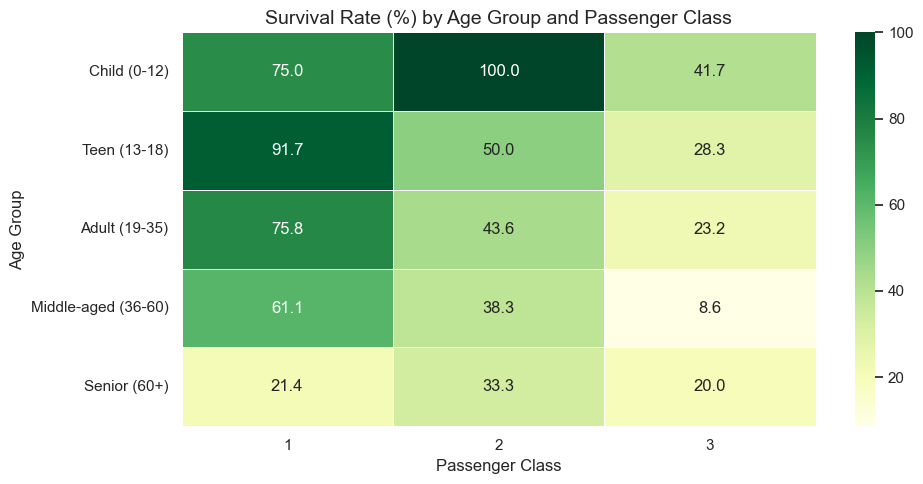

In [20]:
# Survival heatmap — Pclass vs AgeGroup
fig, ax = plt.subplots(figsize=(10, 5))

pivot = df.pivot_table(values='Survived', index='AgeGroup',
                        columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            ax=ax, linewidths=0.5)
ax.set_title('Survival Rate (%) by Age Group and Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Age Group')
plt.tight_layout()
plt.savefig('../screenshots/Survival Rate (%) by Age Group and Passenger Class.png')
plt.show()


- Create FamilySize = SibSp + Parch + 1
- Create IsAlone = 1 if FamilySize == 1 else 0
- Extract Title from Name (Mr, Mrs, Miss, Master)
- Create HasCabin binary feature from Cabin
- Impute Age using median by Pclass + Sex groups
- Apply log transformation to Fare

### 8. Key Insights
Here are the most important findings from our EDA:
##### 👥 Gender
Women had a ~74% survival rate vs only ~19% for men
"Women and children first" policy clearly visible in the data
Gender is likely the strongest predictor of survival
##### 🎟️ Passenger Class
1st class passengers had ~63% survival rate vs ~47% for 2nd class and ~24% for 3rd class
Wealthier passengers had better access to lifeboats
Pclass is a strong proxy for socioeconomic status
##### 👶 Age
Children (0-12) had the highest survival rate among age groups
Seniors (60+) had one of the lowest survival rates
Age alone is a weaker predictor but important when combined with class and gender
##### 💰 Fare
Higher fare strongly correlates with survival
Fare is highly skewed — log transformation brings it closer to normal distribution
Fare and Pclass are correlated — both capture wealth information
##### 🚢 Embarkation Port
Cherbourg (C) passengers had the highest survival rate (~55%)
This is likely because Cherbourg passengers were predominantly 1st class
Embarkation port is an indirect feature — its effect is mediated by class
##### 🔢 Missing Values
Cabin is mostly missing (~77%) — best converted to binary HasCabin feature
Age should be imputed by median within Pclass + Sex groups
Embarked missing values can be filled with mode (Southampton)
